## This is a notebook showing how to perform frequentist model selection with an information criterion supported by Resolve. ##

In [4]:
import numpy as np, matplotlib.pyplot as plt
import mhealpy as mhp
from resolve.frequentist import information_criterion_analysis

### You'll need optimal statistic outputs as the input for this notebook. Use Defiant to get some. ###

In [ ]:
rhok = # the PFOS cross-correlations (Npairs,)
Ck = # the PFOS pair-covariance matrix (Npairs, Npairs)
Sk = # the PFOS amplitude
rho = rhok / Sk # scale the cross-correlations
C = Ck / Sk**2 # scale the covariance matrix
del rhok, Ck, Sk # don't need these anymore
psrs_theta = [p.theta for p in psrs] # where psrs is a list of e.g. enterprise pulsar objects
psrs_phi = [p.phi for p in psrs] # you can alternatively load in an array of positions if you have it saved already

#### The next cell shows how to perform an information criterion analysis.
#### It takes seconds if you pass return_uncertainties=False to the function, or minutes if you want uncertainties

In [5]:
# the return format is a 3-tuple if you use return_uncertainties=False
# i.e., information_criteria, meshes, log10_densities =  information_criterion_analysis(rho, C, psrs_theta, psrs_phi, return_uncertainties=False)
information_criteria, meshes, log10_densities, uncertainties =  information_criterion_analysis(rho, C, psrs_theta, psrs_phi)
# information_criterion_analysis by default uses the BIC. You can set it to AIC by passing information_criterion = 'AIC' to the function above.
preferred_mesh = meshes[np.argmin(information_criteria)] # an array of UNIQ indices; has shape (Npix,)
opt_densities = log10_densities[np.argmin(information_criteria)] # an array of log10_densities; has shape (Npix,)
lower_limits, upper_limits = uncertainties # each of these limits has shape (Npix,) and correspond to 1-sigma by default

## Here is a diagnostic examining the information criterion to ensure it reached a minimum in the range of iterations we performed. ##

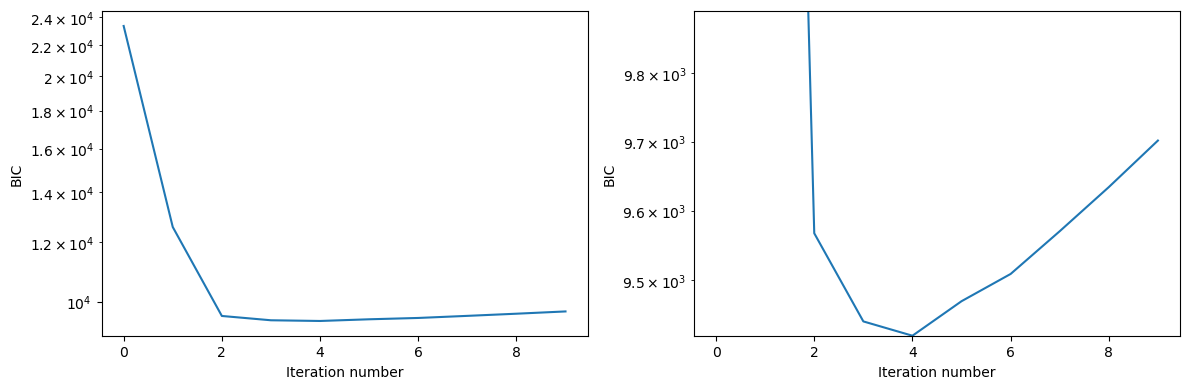

In [6]:
fig,ax = plt.subplots(1,2,figsize=(12,4))
for axis in ax:
    axis.plot(information_criteria)
    axis.set_yscale('log')
    axis.set_xlabel('Iteration number')
    axis.set_ylabel('BIC') # change to AIC if you used AIC
ax[1].set_ylim(np.min(information_criteria), 1.05*np.min(information_criteria)) # zoom in
plt.tight_layout();

### Looks like the optimal mesh was at iteration index 4. ###

## Next, we'll plot the optimal mesh. ##

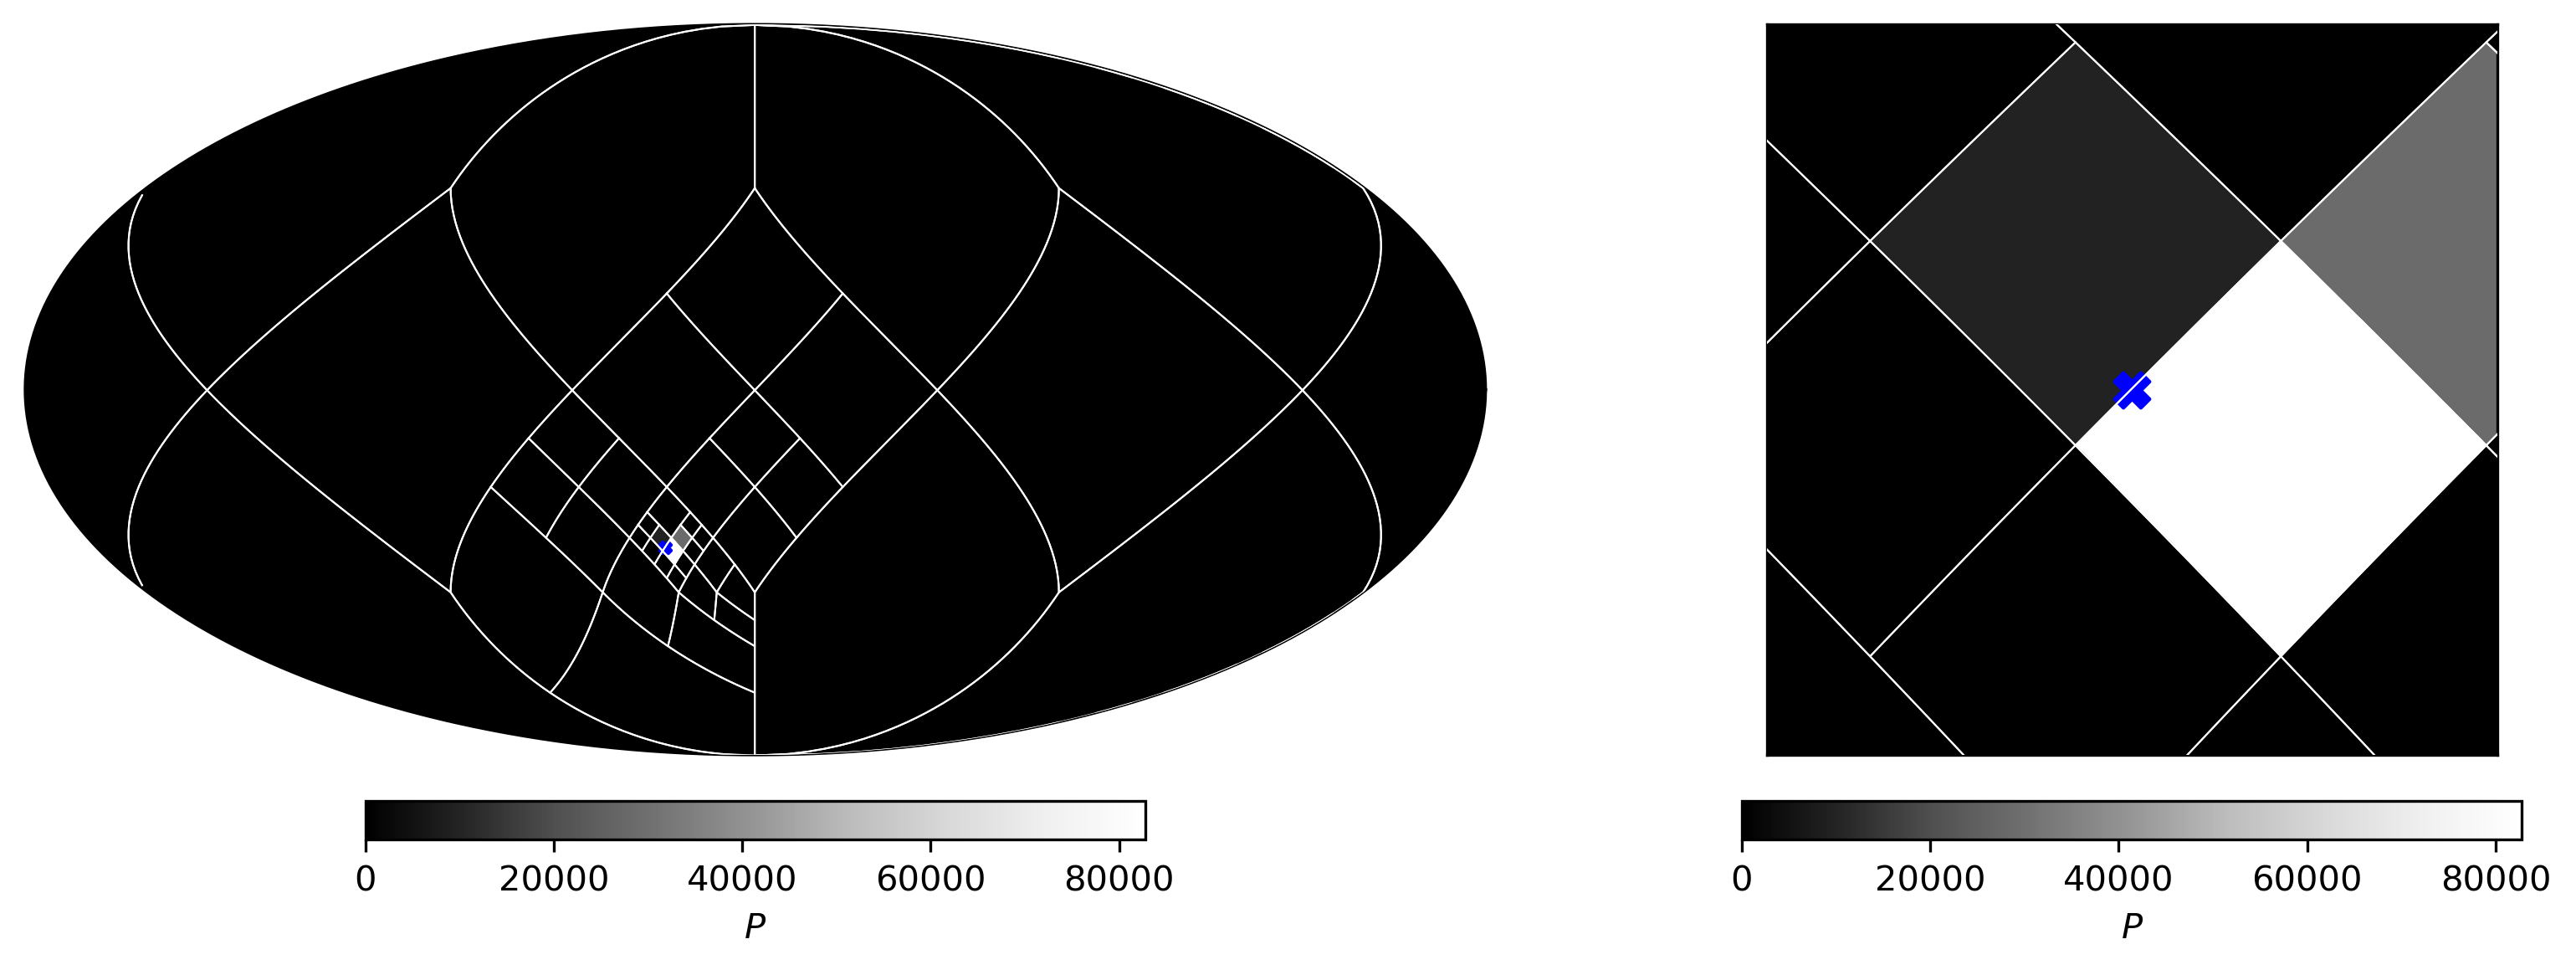

In [7]:
figure = plt.figure(figsize=(12,4), dpi=300)

mollweide = figure.add_subplot(1,2,1, projection = 'mollview', rot=180) # format is (rows, cols, ax_idx, projection = )
cartesian = figure.add_subplot(1,2,2, projection = 'cartview',
                    lonra=np.rad2deg(3.57)+np.array([-5,5]), latra=90-np.rad2deg(2.13)+np.array([-5,5])) # viewing window is +/- 5 deg from center
m = mhp.HealpixMap(uniq=preferred_mesh, data=10**opt_densities, density=True)

for ax, markersize in zip([mollweide, cartesian], [10,100]):
    fig,_ = m.plot(ax=ax, cmap='Greys_r', cbar=False)
    m.plot_grid(ax=ax, linewidth=.5, color='white')
    ax.scatter(np.rad2deg(3.57), 90-np.rad2deg(2.13), transform=ax.get_transform('world'),
          s=markersize, color='blue', marker='X')
    plt.colorbar(fig, label='$P$', orientation='horizontal', pad=.05, shrink=0.5)
plt.tight_layout();